# HW 4: Unsupervised learning

Student surname and name: **Kovtunyak Ivan**

----

Dear students,

This homework includes tasks on unsupervised learning: dimensionality reduction (PCA) and clustering. You will compress a set of student-questionnaire scales into a few components, test whether they still predict the math score, then cluster students on the reduced dimensions and interpret the result. Complete all tasks and submit the `.ipynb` file to **SmartLMS**. Make sure to include your surname and name in the filename.

Please pay attention, this is an individual work. Do not share your code with other students.

**Important note on LLM usage.** It is OK to consult with an LLM, but not just copying parts of the code without re-checking. If you use anything, try to show that you understand the meaning and the concepts you use. If your work contains a model output that contradicts your numbers, it can be understood that your task was done not by yourself.

**Per-student randomness.** This homework uses a per-student random seed derived from your name (see Task 1.1 helper cell). This means **your train/test split, the signs of your principal components and your cluster assignments will differ from your classmates'** — interpret your own numbers, not a generic answer.

Don't delete task descriptions so I can see what code corresponds to what task. Run your code before sending — make sure it works without errors.

Each task brings up to 2 scores. You can get up to 10 scores in total.

Deadline: **23:59, 16 June**. Late submissions will not be accepted.

## Dataset

**`students_4e.xlsx`** — questionnaire responses from 2,661 school students. Each row is one student: a standardized **math score** (the target for the regression part), two demographics (`sex`, `location`), and 20 Likert items (1–5) grouped into five scales — school satisfaction, peer relationships, health, learning methods, and math self-efficacy.

Drop `students_4e.xlsx` into the same folder as this notebook.

**Required packages:** standard scientific stack (`numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`, `scipy`).

## Task 1. Data reading and preparation (0–2 scores)

### Task 1.1. Setup imports and per-student seed (helper — run this cell as-is)

The cell below derives a seed **deterministically from your name** and seeds NumPy / Python's `random` globally. **Every `random_state` later in this homework must reference `SEED`, not a hardcoded number like 42.** The auto-grader reproduces this seed from your name and re-checks your outputs.

In [1]:
# === Task 1.1 helper — run this cell as-is, do NOT edit anything below except STUDENT_NAME ===
import hashlib
import random
import numpy as np

STUDENT_NAME = "Kovtunyak Ivan Ivanovich"

# Lowercase + strip so capitalisation/leading-space typos don't change the seed.
_clean = STUDENT_NAME.strip().lower()
_placeholder = "write your full name here (latin, e.g. 'ivanov ivan ivanovich')" # Do not change this line!
if _clean == _placeholder or not _clean:
    raise ValueError("Set STUDENT_NAME to your full name before running this cell.")

SEED = int(hashlib.md5(_clean.encode()).hexdigest()[:8], 16)
random.seed(SEED)
np.random.seed(SEED)

print(f"STUDENT_NAME = {STUDENT_NAME!r}")
print(f"SEED         = {SEED}")

STUDENT_NAME = 'Kovtunyak Ivan Ivanovich'
SEED         = 193146654


### Task 1.2. Read the data

- Import the libraries you need (`pandas`, `numpy`, `seaborn`, `matplotlib`, ...).
- Read `students_4e.xlsx` with `pd.read_excel`. Save it to `data`.
- Show `data.info()` and the **last 10 rows**.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

data = pd.read_excel('students_4e.xlsx')
data.info()
data.tail(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2661 entries, 0 to 2660
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   location             2661 non-null   object 
 1   student_id           2661 non-null   int64  
 2   sex                  2655 non-null   object 
 3   math                 2661 non-null   float64
 4   sch_satisfaction3    2421 non-null   float64
 5   sch_satisfaction4    2386 non-null   float64
 6   sch_satisfaction6    2321 non-null   float64
 7   mates_relationship5  2416 non-null   float64
 8   mates_relationship7  2418 non-null   float64
 9   mates_relationship9  2411 non-null   float64
 10  health1              2447 non-null   float64
 11  health2              2437 non-null   float64
 12  health3              2429 non-null   float64
 13  health5              2432 non-null   float64
 14  health6              2423 non-null   float64
 15  health7              2428 non-null   f

,location,student_id,sex,math,sch_satisfaction3,sch_satisfaction4,sch_satisfaction6,mates_relationship5,mates_relationship7,mates_relationship9,...,health6,health7,learning_method1,learning_method2,learning_method3,learning_method4,learning_method5,math_selfefficacy1,math_selfefficacy2,math_selfefficacy3
2651,город,52007057796,ж,-0.54,4.0,3.0,4.0,4.0,1.0,1.0,...,5.0,1.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0
2652,город,52026564566,м,-1.50,4.0,3.0,3.0,3.0,2.0,3.0,...,1.0,1.0,3.0,2.0,4.0,3.0,4.0,2.0,2.0,3.0
2653,город,52026859684,м,-1.70,4.0,4.0,4.0,4.0,4.0,2.0,...,1.0,5.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,4.0
2654,город,52036304393,м,0.47,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2655,город,52022781733,м,0.08,4.0,3.0,3.0,3.0,1.0,2.0,...,5.0,2.0,1.0,4.0,3.0,4.0,3.0,3.0,2.0,3.0
2656,город,52049023141,м,0.18,2.0,2.0,3.0,3.0,3.0,1.0,...,2.0,2.0,1.0,1.0,3.0,2.0,1.0,4.0,3.0,3.0
2657,город,52020540312,м,-4.76,4.0,4.0,4.0,3.0,3.0,3.0,...,4.0,1.0,3.0,3.0,4.0,4.0,4.0,3.0,3.0,3.0
2658,город,52031462856,ж,1.22,2.0,3.0,3.0,3.0,2.0,2.0,...,4.0,2.0,2.0,3.0,2.0,3.0,2.0,3.0,3.0,3.0
2659,город,52052495545,ж,0.30,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2660,город,52044863862,м,-1.31,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# The 20 questionnaire items, grouped into five scales. These are the features for PCA.
scales = [
    'sch_satisfaction3', 'sch_satisfaction4', 'sch_satisfaction6',
    'mates_relationship5', 'mates_relationship7', 'mates_relationship9',
    'health1', 'health2', 'health3', 'health5', 'health6', 'health7',
    'learning_method1', 'learning_method2', 'learning_method3', 'learning_method4', 'learning_method5',
    'math_selfefficacy1', 'math_selfefficacy2', 'math_selfefficacy3',
]

**Data description (columns):**

**Target (regression part):**
- `math` — standardized math score.

**Demographics (held out of the features; used only to profile clusters in Task 5):**
- `sex` — `м` / `ж`
- `location` — `город` / `село`

**Questionnaire items (the `scales` list, all 1–5):**
- `sch_satisfaction3/4/6` — school satisfaction
- `mates_relationship5/7/9` — relationships with classmates
- `health1/2/3/5/6/7` — health and well-being
- `learning_method1…5` — learning methods / study habits
- `math_selfefficacy1/2/3` — confidence in maths

`student_id` is an identifier — do not use it as a feature.

### Task 1.3. Recode sex and location

We hold `sex` and `location` out of the modelling features and use them only later, to profile the clusters (Task 5). Recode them to 0/1 by running the cell below as-is.

In [4]:
data.sex = data.sex.replace({"м": 1, "ж": 0})              # 1 = boys
data.location = data.location.replace({"город": 0, "село": 1})  # 1 = rural
print(data.sex.value_counts(dropna=False))
print(data.location.value_counts(dropna=False))

sex
1.0    1344
0.0    1311
NaN       6
Name: count, dtype: int64
location
0    2480
1     181
Name: count, dtype: int64


### Task 1.4. Duplicates, missing values, imputation

- Print the number of fully duplicated rows; drop them if there are any.
- Show the **percent of missing values per variable**, in descending order, rounded to 2 decimals.
- Impute the missing values with the **most frequent value** of each column (`SimpleImputer(strategy='most_frequent')` from `sklearn.impute`). Keep the result as a `DataFrame` with the **same columns and index** (later tasks rely on the row index).
- Print the total number of missing values after imputation — it must be 0.

In [5]:
print("Duplicated rows:", data.duplicated().sum())
data = data.drop_duplicates()

missing_pct = (data.isna().mean() * 100).round(2)
print(missing_pct.sort_values(ascending=False))

data[:] = SimpleImputer(strategy='most_frequent').fit_transform(data)
print("Total NaN after imputation:", data.isna().sum().sum())
#пункты анкеты - категориальные оценки 1-5, поэтому заполняем модой, а не средним

Duplicated rows: 0
sch_satisfaction6      12.78
sch_satisfaction4      10.33
learning_method5       10.00
learning_method3        9.66
learning_method2        9.62
mates_relationship9     9.39
learning_method4        9.39
mates_relationship5     9.21
mates_relationship7     9.13
sch_satisfaction3       9.02
math_selfefficacy3      8.98
health6                 8.94
learning_method1        8.91
health7                 8.76
health3                 8.72
math_selfefficacy2      8.68
health5                 8.61
math_selfefficacy1      8.46
health2                 8.42
health1                 8.04
sex                     0.23
student_id              0.00
math                    0.00
location                0.00
dtype: float64
Total NaN after imputation: 0


### Task 1.5. Descriptive statistics, features/target, correlation heatmap

- Show a table of descriptive statistics — **mean, median, std, min, max** — with variables in rows and statistics in columns (exclude `student_id`).
- Build `X` — the 20 questionnaire items from the `scales` list — and `y` — the `math` score.
- Dimensionality reduction is based on correlations, so draw a heatmap of the correlations **within `X`**: annotate the values, round to 2 decimals, choose a `cmap` that makes stronger correlations stand out, and show only the cells **below the diagonal**.
- Looking at the heatmap, you should see several blocks of items that correlate more strongly within a block than across blocks.

In [6]:
desc = data.drop(columns='student_id').describe().T
desc = desc[['mean', '50%', 'std', 'min', 'max']].rename(columns={'50%': 'median'}).round(2)
desc

,mean,median,std,min,max
location,0.07,0.00,0.25,0.00,1.00
sex,0.51,1.00,0.50,0.00,1.00
math,-0.36,-0.41,1.17,-5.34,5.71
sch_satisfaction3,3.67,4.00,0.68,1.00,4.00
sch_satisfaction4,3.53,4.00,0.71,1.00,4.00
sch_satisfaction6,3.67,4.00,0.66,1.00,4.00
mates_relationship5,3.54,4.00,0.73,1.00,4.00
mates_relationship7,2.12,2.00,0.93,1.00,4.00
mates_relationship9,2.30,2.00,0.92,1.00,4.00
health1,3.76,4.00,1.40,1.00,5.00


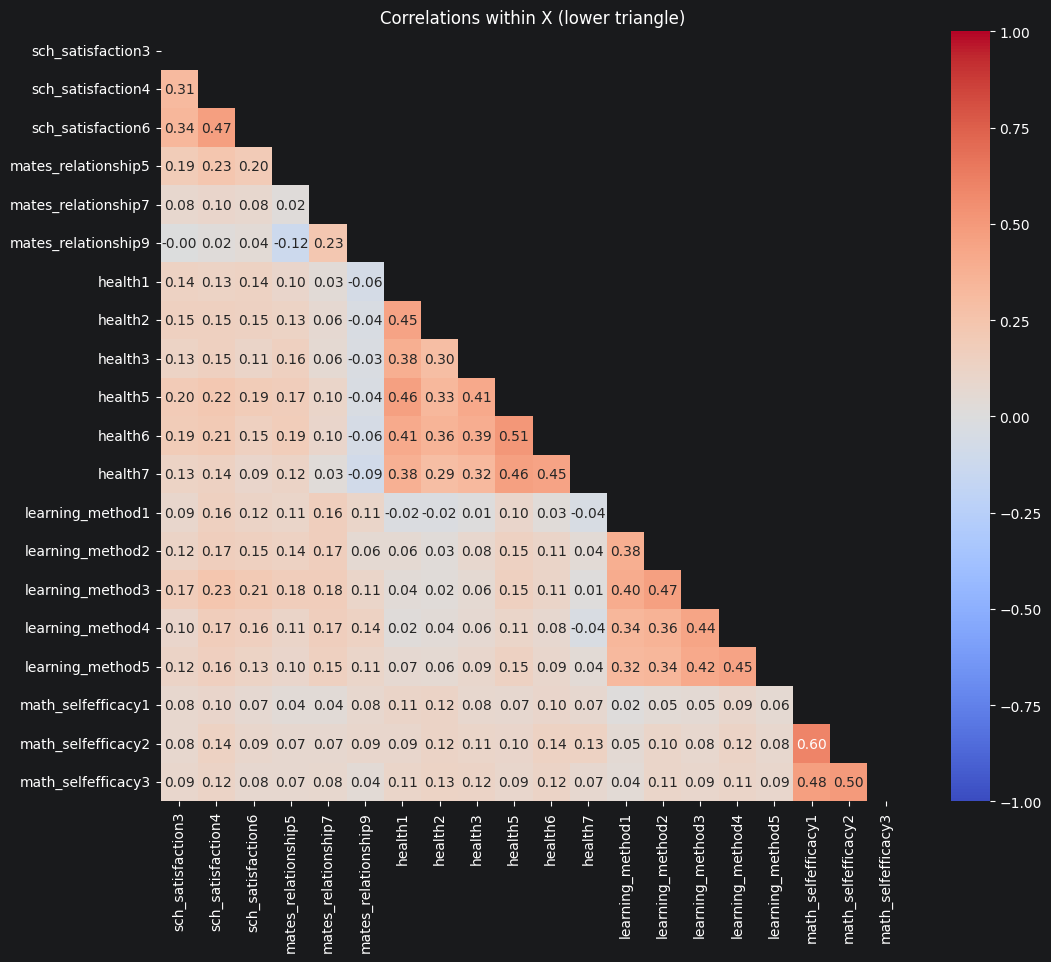

In [7]:
X = data[scales].astype(float)
y = data['math'].astype(float)

plt.figure(figsize=(12, 10))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlations within X (lower triangle)')
plt.show()

### Task 1.6. Train/test split and scaling

- Split `X`, `y` into train and test with `train_test_split(..., test_size=0.15, random_state=SEED, shuffle=True)`.
- Print the shapes of `X_train` and `X_test`.
- PCA is sensitive to scale, so standardize the features: fit a `StandardScaler` **on `X_train` only**, then transform both train and test. Save the results as `X_train_scaled` and `X_test_scaled` (keep `X_train` itself as the original data frame — you will need its row index in Task 5). Use the scaled arrays in Tasks 2 and 3.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, shuffle=True)
print("X_train:", X_train.shape, " X_test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit только на train, чтобы не было утечки
X_test_scaled = scaler.transform(X_test)


X_train: (2261, 20)  X_test: (400, 20)


## Task 2. Principal Component Analysis (0–2 scores)

### Task 2.1. Variance explained by each component (on train)

- Fit `PCA(random_state=SEED)` on the scaled train data (`X_train_scaled`).
- Make a line plot of the **share of variance explained by each component**.
- Make the figure bigger; add a title and axis labels.
- Make the x-ticks start at 1 and go up to the number of features, with step 1.
- Add a vertical line at the elbow point (the bend after which extra components add little). The elbow can be soft here — pick a reasonable point.

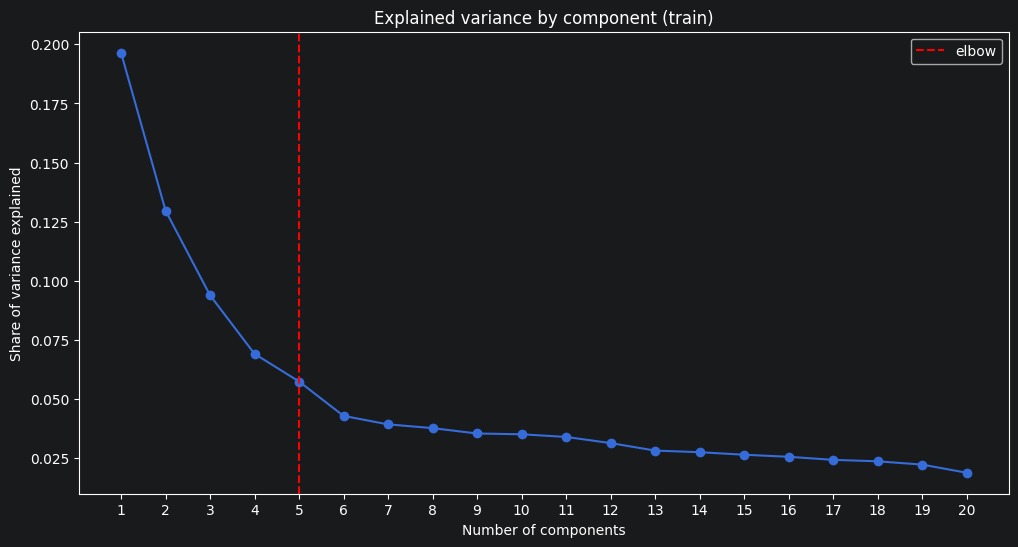

In [9]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_scaled)
evr = pca_full.explained_variance_ratio_   # доля дисперсии каждой компоненты

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(evr) + 1), evr, marker='o')
plt.axvline(x=5, color='red', linestyle='--', label='elbow')   # локоть выбираем субъективно
plt.xticks(range(1, len(evr) + 1))
plt.title('Explained variance by component (train)')
plt.xlabel('Number of components')
plt.ylabel('Share of variance explained')
plt.legend()
plt.show()
#резкий спад после первых компонент, дальше почти плато - локоть мягкий

### Task 2.2. Cumulative explained variance (on train)

- Make a line plot of the **cumulative** explained variance (in percent) against the number of components.
- x-ticks from 1 to the number of features, step 1.
- Add a title and axis labels; make the figure bigger.

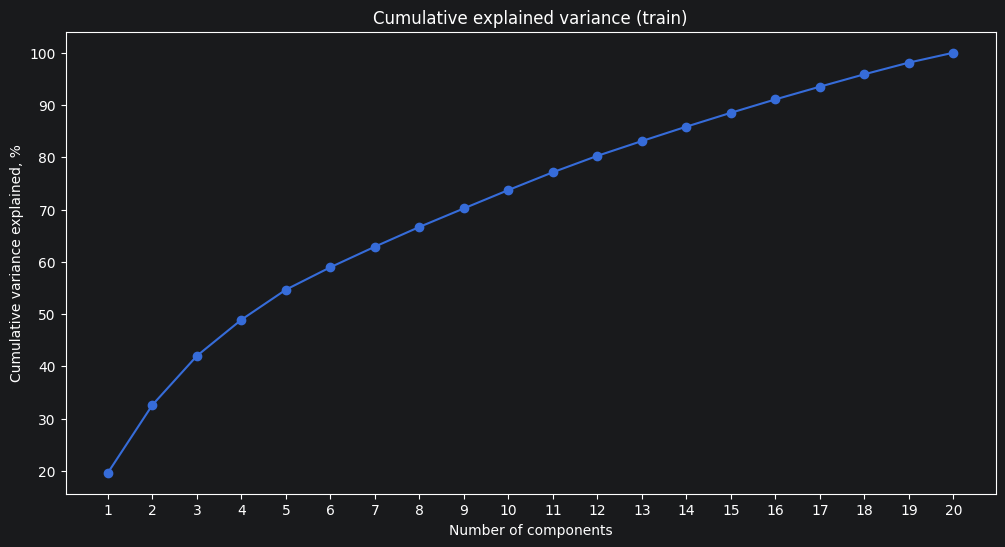

In [10]:
cum = np.cumsum(evr) * 100   # накопленная доля дисперсии в процентах

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cum) + 1), cum, marker='o')
plt.xticks(range(1, len(cum) + 1))
plt.title('Cumulative explained variance (train)')
plt.xlabel('Number of components')
plt.ylabel('Cumulative variance explained, %')
plt.show()


### Task 2.3. Choose the number of components

Look at both plots. The elbow may sit at a slightly different place in each — that is normal. Decide how many components you will keep for the rest of the homework, then print how much cumulative variance that number explains.

**How many components did you keep and why? (2–4 sentences, referring to your own plots and the cumulative variance you reach.)**

*First 5 components give 20, 13, 9, 7 and 6 percents - there is a clear
difference between each step, but from the 6th component the difference
becomes very small (about 4% and less) and the line goes almost flat, so
the rest is mostly noise. On the cumulative plot these 5 components reach
about 55% of the variance.I also keep 5 because the questionnaire has 5 scales, so this number fits
the data well.*

In [11]:
# Print the cumulative variance explained by the number of components you chose
n_components = 5   # подставь своё число по своему графику
print(f"Cumulative variance with {n_components} components: {cum[n_components - 1]:.2f}%")

Cumulative variance with 5 components: 54.67%


### Task 2.4. Fit PCA with the chosen number of components

- Fit `PCA(n_components=<your number>, random_state=SEED)` on `X_train_scaled`.
- Transform train and test; save them as `X_train_reduced` and `X_test_reduced`.
- Print the shapes of `X_train_reduced` and `X_test_reduced`.

In [12]:
pca = PCA(n_components=n_components, random_state=SEED)
X_train_reduced = pca.fit_transform(X_train_scaled)
X_test_reduced = pca.transform(X_test_scaled)
print("reduced train:", X_train_reduced.shape, " reduced test:", X_test_reduced.shape)


reduced train: (2261, 5)  reduced test: (400, 5)


### Task 2.5. Component loadings

- Compute the **loadings** — the correlations of the components with the original features (i.e. `pca.components_.T * np.sqrt(pca.explained_variance_)`, not the raw `pca.components_`).
- Plot a heatmap of the loadings; annotate the values, round to 2 decimals.
- Add a title; make the figure bigger.

*The sign of a component is arbitrary in PCA, so a component may come out flipped relative to a classmate's — that is fine, read the pattern, not the sign.*

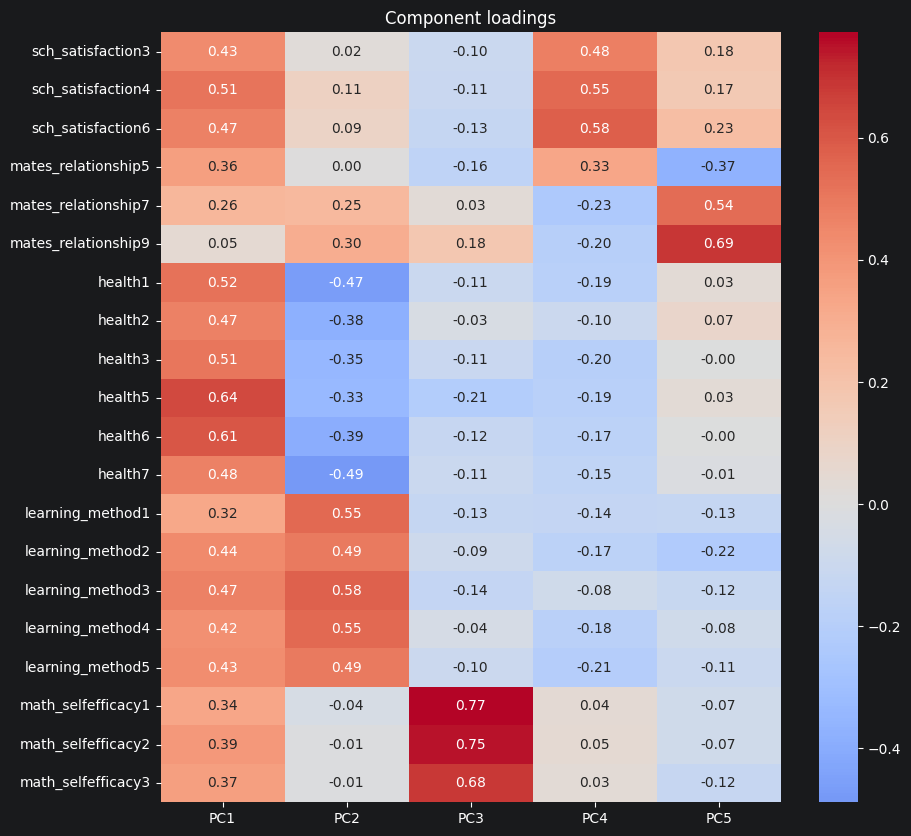

In [13]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
load_df = pd.DataFrame(loadings, index=scales,
                       columns=[f'PC{i+1}' for i in range(n_components)])

plt.figure(figsize=(10, 10))
sns.heatmap(load_df, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Component loadings')
plt.show()
#компоненты почти совпали со шкалами анкеты - те же блоки, что на корр. карте в 1.5, плюс общий фактор PC1


### Task 2.6. Interpret and name the components

- Write code that returns, **for each component, the feature with the largest absolute loading**.
- PCA is often hard to interpret, but using the heatmap and the strongest-loading features, give each component a short interpretation.
- Give each component a short name and collect the names, in component order, into a list `component_names`.

**Your interpretation:
- PC1: all features load positive, so it is a general factor - a student who
answers high on one scale usually answer high on the others too. Health loads
strongest (health5 = 0.64), so I read PC1 as general well-being.
- PC2: learning methods load positive (learning_method3 = 0.58) but health is
negative (about -0.4), so PC2 is a contrast between study habits and health.
- PC3: only math self-efficacy load strong (math_selfefficacy1 = 0.77), the rest
is near zero, so clearly it is confidence in maths.
- PC4: school satisfaction load strongest (sch_satisfaction6 = 0.58), so PC4 is
satisfaction with school.
- PC5: peer relationships are high (mates_relationship9 = 0.69, mates7 = 0.54),
but mates_relationship5 is negative, so PC5 is relations with classmates.**

In [14]:
# Feature with the max |loading| per component, and the component_names list.
# Make sure component_names is created and printed — Tasks 3.4 and 5.1 reuse it.
# Your code here
for col in load_df.columns:
    top = load_df[col].abs().idxmax()
    print(f"{col}: {top} ({load_df.loc[top, col]:.2f})")

component_names = [
    'General well-being',
    'Learning methods vs health',
    'Math self-efficacy',
    'School satisfaction',
    'Peer relationships',
]
print(component_names)

PC1: health5 (0.64)
PC2: learning_method3 (0.58)
PC3: math_selfefficacy1 (0.77)
PC4: sch_satisfaction6 (0.58)
PC5: mates_relationship9 (0.69)
['General well-being', 'Learning methods vs health', 'Math self-efficacy', 'School satisfaction', 'Peer relationships']


## Task 3. Does dimensionality reduction affect prediction? (0–2 scores)

### Task 3.1. Regression on the original features

- Fit an ordinary least squares regression (`LinearRegression`) to predict `math` from the **scaled original features** (`X_train_scaled`). Make predictions.
- Write a function `print_metrics(y_true, y_pred, name)` that prints `name` and the **RMSE, MAE and $R^2$**. Use it to report metrics on train and on test. You will reuse this function below.

In [15]:
def print_metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"=== {name} ===")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE:  {mae:.3f}")
    print(f"R2:   {r2:.3f}")

lr = LinearRegression().fit(X_train_scaled, y_train)
print_metrics(y_train, lr.predict(X_train_scaled), 'Original features - train')
print_metrics(y_test, lr.predict(X_test_scaled), 'Original features - test')
#R^2 низкий и на train, и на test - успеваемость зависит далеко не только от критериев в анкете

=== Original features - train ===
RMSE: 1.076
MAE:  0.819
R2:   0.142
=== Original features - test ===
RMSE: 1.143
MAE:  0.887
R2:   0.108


### Task 3.2. Coefficients on the original features

- Make a **horizontal** bar plot: features on the y-axis, coefficients on the x-axis, sorted in descending order.
- Add a title, remove the axis labels; make the figure bigger.

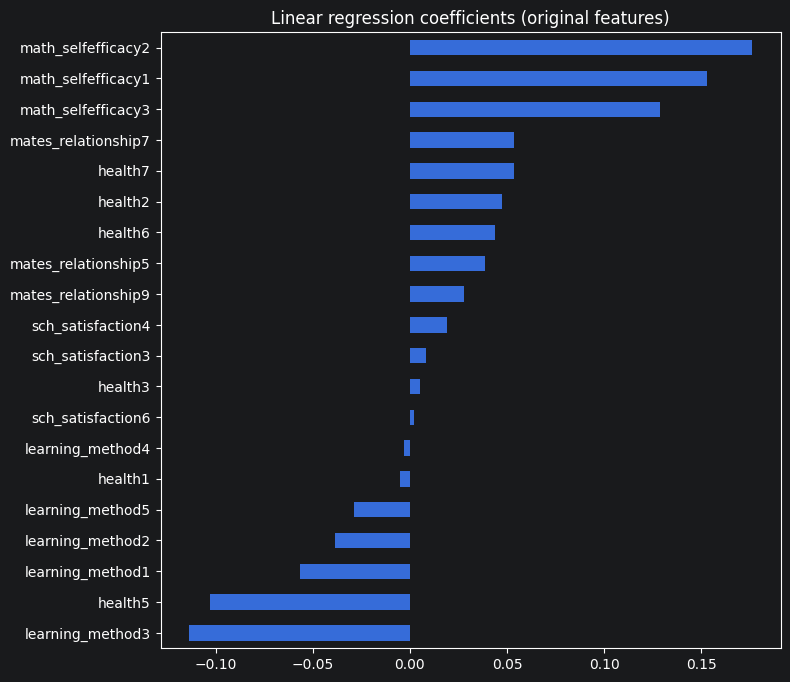

In [16]:
coef = pd.Series(lr.coef_, index=scales).sort_values()

plt.figure(figsize=(8, 8))
coef.plot(kind='barh')
plt.title('Linear regression coefficients (original features)')
plt.show()


### Task 3.3. Regression on the principal components

- Fit OLS to predict `math` from the **principal components** (`X_train_reduced`). Make predictions.
- Use `print_metrics` to report RMSE, MAE and $R^2$ on the reduced train and test.

**Compare these metrics with the regression on the original features. How did the model quality change after reducing the dimensionality? (2–3 sentences.)**

*The metrics are almost the same on the original features and on the 5
components. On test, R2 is 0.108 with the original features and 0.099 with
the components, and RMSE (about 1.14) and MAE (about 0.89) almost do not
change. So reducing from 20 features to 5 components made the quality only
a little worse (R2 lower by about 0.01) - we kept almost all the predictive
power with 4 times fewer features.*

In [17]:
lr_pca = LinearRegression().fit(X_train_reduced, y_train)
print_metrics(y_train, lr_pca.predict(X_train_reduced), 'PCA components - train')
print_metrics(y_test, lr_pca.predict(X_test_reduced), 'PCA components - test')
#метрики почти такие же, как на исходных признаках - 5 компонент сохранили почти всю предсказательную силу


=== PCA components - train ===
RMSE: 1.083
MAE:  0.822
R2:   0.132
=== PCA components - test ===
RMSE: 1.149
MAE:  0.889
R2:   0.099


### Task 3.4. Coefficients on the components

- Use your `component_names`.
- Make a horizontal bar plot: components on the y-axis, coefficients on the x-axis, sorted in descending order.
- Add a title, remove the axis labels; make the figure bigger.

Looking at this plot together with the loadings heatmap, give short answers:
- Why can some component coefficients be negative?
- What might the components with the largest coefficients mean for the math score?

**Your answers:**
- Why some coefficients are negative: in PCA the sign of a component is random,
so negative coefficient just means that bigger value on this component goes
with lower math score. It does not mean the scale is bad.
- Largest coefficient: the biggest coefficient is on Math self-efficacy
component, so confidence in maths predict the math score the best. It makes
sense, because students who are sure in maths usually have higher score.
General well-being has small coefficient, so answering high on everything
adds little when self-efficacy is already in the model.

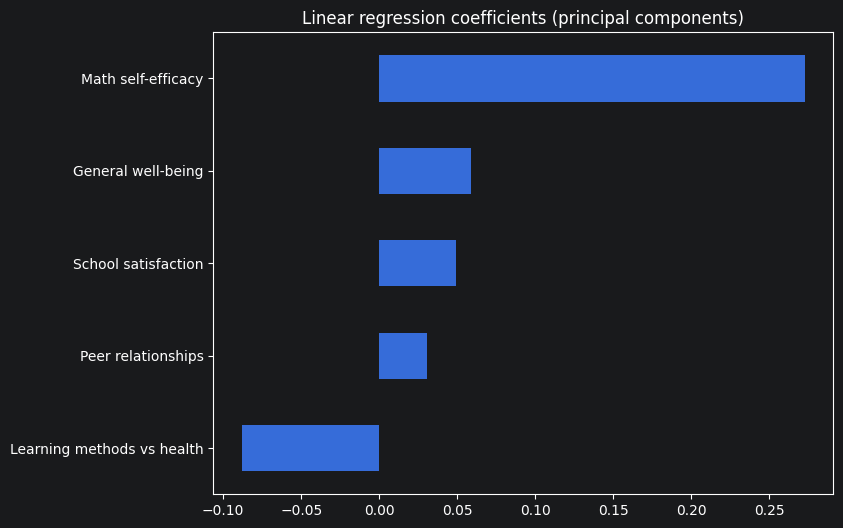

In [18]:
coef_pca = pd.Series(lr_pca.coef_, index=component_names).sort_values()

plt.figure(figsize=(8, 6))
coef_pca.plot(kind='barh')
plt.title('Linear regression coefficients (principal components)')
plt.show()

## Task 4. Clustering (0–2 scores)

### Task 4.1. Hierarchical clustering

- On the **principal components** of the train set (`X_train_reduced`), run agglomerative clustering — choose a sensible distance metric and linkage method (e.g. euclidean distance with ward linkage).
- Plot the dendrogram (`scipy.cluster.hierarchy.dendrogram` on a `linkage` matrix).

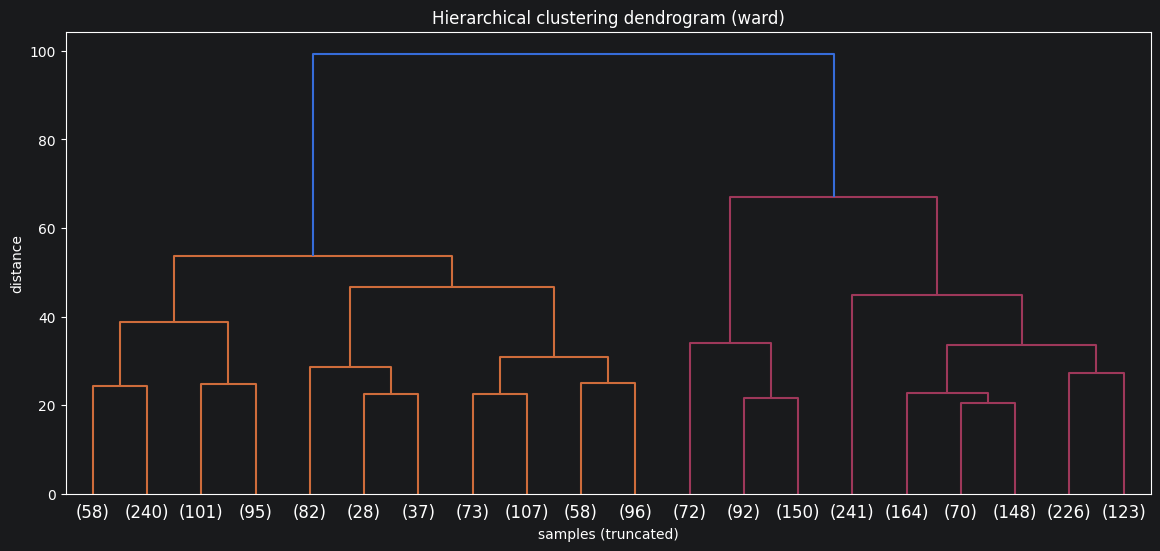

In [19]:
Z = linkage(X_train_reduced, method='ward', metric='euclidean')   # матрица слияний

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=20, show_leaf_counts=True)
plt.title('Hierarchical clustering dendrogram (ward)')
plt.xlabel('samples (truncated)')
plt.ylabel('distance')
plt.show()
#дерево распадается на 2 крупные ветви, сам длинный разрыв высоты наблюдается на верхних стволах (100-67=33)

### Task 4.2. WSSE (elbow) over the number of clusters

- Fit `KMeans(random_state=SEED)` on the principal components (`X_train_reduced`) for `k` from 2 to 10.
- Plot the within-cluster sum of squared errors (`inertia_`) against `k`.
- Step for the x-ticks = 1; add a title and axis labels; make the figure bigger.

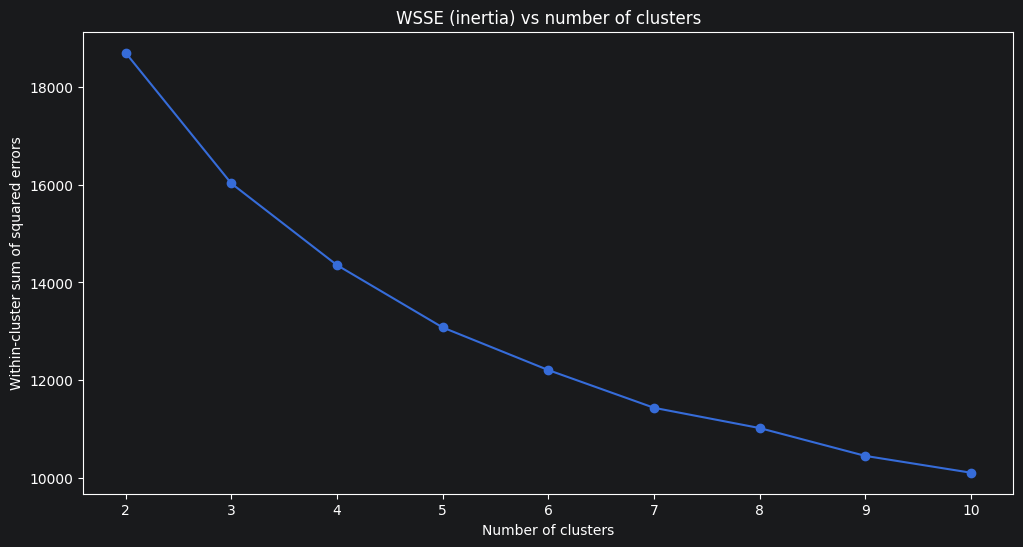

In [20]:
K = range(2, 11)
inertias = []
for k in K:
    km = KMeans(n_clusters=k, random_state=SEED).fit(X_train_reduced)
    inertias.append(km.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(list(K), inertias, marker='o')
plt.xticks(list(K))
plt.title('WSSE (inertia) vs number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Within-cluster sum of squared errors')
plt.show()
#кривая спадает плавно, явной точки падения нет, самое большое падение наблюдается со 2 на 3 шаг, дальше разность уменьшается

### Task 4.3. Silhouette over the number of clusters

- For the same range of `k`, plot the **silhouette score** against `k`.
- Step for the x-ticks = 1; add a title and axis labels; make the figure bigger.

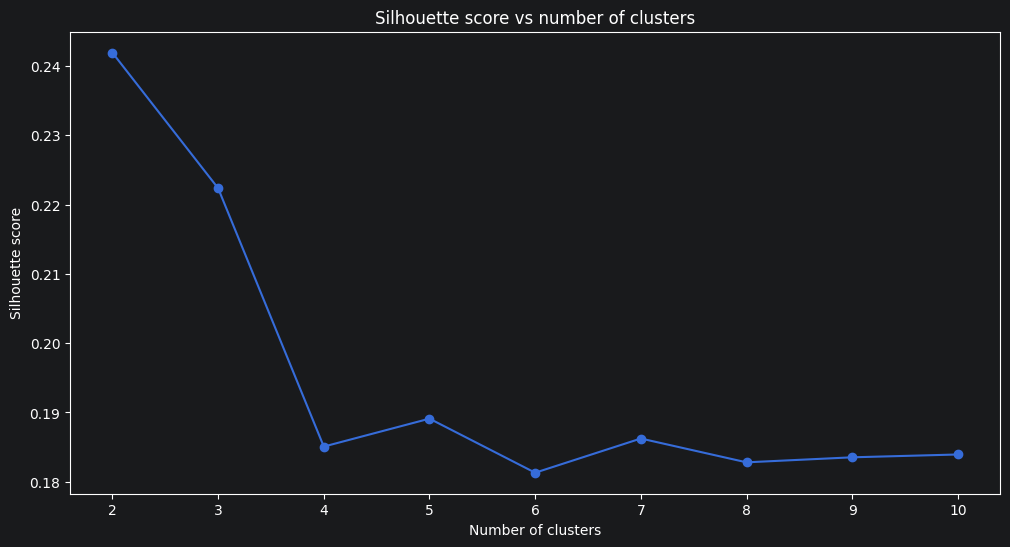

In [21]:
sils = []
for k in K:
    km = KMeans(n_clusters=k, random_state=SEED).fit(X_train_reduced)
    sils.append(silhouette_score(X_train_reduced, km.labels_))

plt.figure(figsize=(12, 6))
plt.plot(list(K), sils, marker='o')
plt.xticks(list(K))
plt.title('Silhouette score vs number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.show()
#силуэт максимален при k=2 (~0.24), дальше резко падает => данные лучше всего делятся на 2 группы

### Task 4.4. Choose the number of clusters

Using the dendrogram, the WSSE elbow and the silhouette curve, decide how many clusters to use.

**How many clusters did you choose and why? (2–4 sentences, referring to your own three plots.)**

*I choose 2 clusters. The silhouette is the biggest on k = 2 (about 0.24) and
then it drops, so 2 groups are separated the best. The WSSE line goes down
smoothly and has no clear elbow, so it does not give one clear number. On
the dendrogram the 2 main branches connect on the biggest distance, this
also show 2 groups.*

### Task 4.5. Fit k-means with the chosen number of clusters

- Fit `KMeans(n_clusters=<your number>, random_state=SEED)` on the principal components of the train set.
- Predict clusters on the reduced train and the reduced test; save them as `clusters_train` and `clusters_test` (Task 5 reuses `clusters_train`).
- Print the silhouette score, rounded to 3 decimals, for the reduced train and the reduced test.

**What do these silhouette scores tell us about how well separated the clusters are? (1–2 sentences.)**

*The silhouette is about 0.24 on train and 0.25 on test. This is not high
value, so 2 clusters are separated but the border is not sharp and they
overlap a lot. Train and test are close (test is even a bit higher), so the
clustering better on new data.*

In [22]:
km = KMeans(n_clusters=2, random_state=SEED).fit(X_train_reduced)
clusters_train = km.predict(X_train_reduced)
clusters_test = km.predict(X_test_reduced)

print(f"silhouette train: {silhouette_score(X_train_reduced, clusters_train):.3f}")
print(f"silhouette test:  {silhouette_score(X_test_reduced, clusters_test):.3f}")


silhouette train: 0.242
silhouette test:  0.253


## Task 5. Cluster visualization and interpretation (0–2 scores)

### Task 5.1. Scatter of the first two components

- Using the reduced **train** data, make a scatter plot with the first component on the x-axis and the second on the y-axis, coloring the points by cluster.
- Add a title; use your component names as axis labels; make the figure bigger.

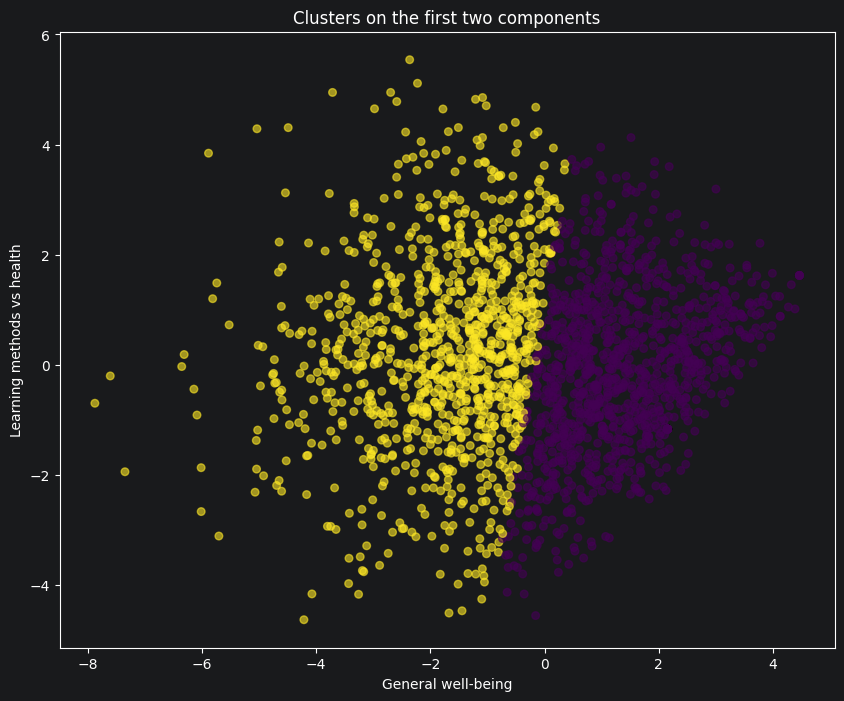

In [23]:
plt.figure(figsize=(10, 8))
plt.scatter(X_train_reduced[:, 0], X_train_reduced[:, 1],
            c=clusters_train, cmap='viridis', s=30, alpha=0.6)
plt.title('Clusters on the first two components')
plt.xlabel(component_names[0])
plt.ylabel(component_names[1])
plt.show()
#между кластерами можно провести вертикальную прямую => разделение по нижней оси general well-being

### Task 5.2. Cluster profiles

- Build a profile data frame. First put the principal components of the reduced train into a `DataFrame` **indexed by `X_train.index`** — `pd.DataFrame(X_train_reduced, columns=component_names, index=X_train.index)` — so its rows line up with the original data. Then add `clusters_train` and the `sex` / `location` columns taken from `data.loc[X_train.index]`.
  - *`train_test_split` shuffles, so `X_train_reduced` is in positional order. You must give it `index=X_train.index` **before** attaching `sex`/`location`, otherwise pandas aligns on mismatched indices and silently fills rows with `NaN`.*
- For each cluster, compute the mean of every component, of `sex` and of `location`, rounded to 3 decimals — print the table.
- Make bar plots, one per cluster (placed in rows), with the components on the x-axis and their cluster means on the y-axis.

         General well-being  Learning methods vs health  Math self-efficacy  \
cluster                                                                       
0                     1.441                      -0.228              -0.024   
1                    -1.800                       0.285               0.030   

         School satisfaction  Peer relationships    sex  location  
cluster                                                            
0                     -0.039              -0.004  0.525     0.066  
1                      0.049               0.005  0.498     0.066  


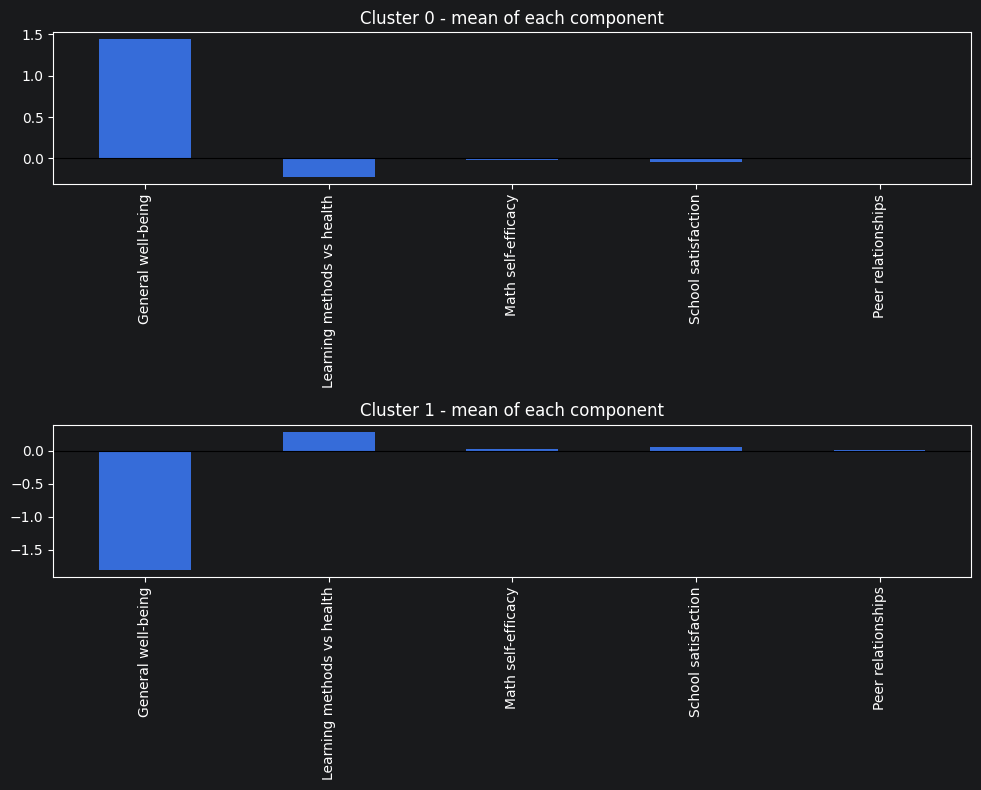

In [24]:
profile = pd.DataFrame(X_train_reduced, columns=component_names, index=X_train.index)
profile['cluster'] = clusters_train
profile['sex'] = data.loc[X_train.index, 'sex']
profile['location'] = data.loc[X_train.index, 'location']

summary = profile.groupby('cluster').mean().round(3)
print(summary)

n_clusters = summary.shape[0]
fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 4 * n_clusters))
for i, ax in enumerate(np.atleast_1d(axes)):
    summary.loc[i, component_names].plot(kind='bar', ax=ax)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Cluster {i} - mean of each component')
plt.tight_layout()
plt.show()
#единственное большое отличие - General well-being (PC1): кластер 0 высокий, кластер 1 низкий

### Task 5.3. Interpret the clusters

Clusters are often hard to interpret. Using the previous plot, your component meanings, and the sex/location composition of each cluster, give a possible interpretation of the clusters.

**Your interpretation: *Cluster 0 are students who answer high on almost all the scales - they feel
quite good about health, school and the rest, so they are happy with most
things. Cluster 1 are the opposite, they answer lower on almost everything,
so they are less happy with most things. The two groups are not different by
one topic (math, friends, school are almost the same) and not by sex or
location (boys and girls, city and village are equal in both). They differ
mainly by how high or low they answer in general - high on everything vs low
on everything.***